# **Install Useful Libraries**

In [110]:
!pip install pandas numpy matplotlib seaborn wordcloud plotly

# **Import Libraries**

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings 
warnings.filterwarnings('ignore') 
plt.style.use('ggplot')

# **Load Dataset**

In [112]:
df=pd.read_csv(r"C:\Users\afzal\Desktop\ML FIles\zomato.csv")
print("Shape:",df.shape)
df.head()

Shape: (56252, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


# **Dataset Information**

In [113]:
df.info() 
print("Missing Values:")
df.isnull().sum()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64

# **Data Cleaning**

## Remove Duplicates

In [114]:
df.drop_duplicates(inplace=True)
print("New Shape:",df.shape)

New Shape: (40549, 13)


## Clean Ratings

In [115]:
def clean_rating(x): 
    try:
        x=str(x) 
        if '/5' in x:
            return float(x.split('/')[0]) 
        return np.nan 
    except:
        return np.nan
df['rate']=df['rate'].apply(clean_rating)
    

## Clean Cost Column

In [116]:
df['approx_cost(for two people)']=df['approx_cost(for two people)'].astype(str).str.replace(",","") 
df['approx_cost(for two people)']=pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')

## Clean Votes Column

In [117]:
df['votes']=pd.to_numeric(df['votes'],errors='coerce')
df['votes'].fillna(df['votes'].median(),inplace=True)

## Clean Book Table

In [118]:
df['book_table'] = df['book_table'].apply(lambda x: x if x in ['Yes', 'No'] else np.nan) 
df['book_table'].fillna(df['book_table'].mode()[0],inplace=True)

## Clean Online Order

In [124]:
df['online_order'] = df['online_order'].apply(lambda x: x if x in ['Yes', 'No'] else np.nan) 
df['online_order'].fillna(df['online_order'].mode()[0],inplace=True)

## Handling Missing Values

In [120]:
df['rate'].fillna(df['rate'].median(),inplace=True) 
df['location'].fillna("Unknown",inplace=True) 
df['cuisines'].fillna("Not Specified",inplace=True)
df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].median(),inplace=True)
df['name'].fillna('Unknown Restaurant', inplace=True)
df['rest_type'].fillna(df['rest_type'].mode()[0],inplace=True)
df['listed_in(type)'].fillna(df['listed_in(type)'].mode()[0],inplace=True)
df['dish_liked'].fillna('Not Mentioned', inplace=True)

## Remove irrelevant columns

In [121]:
df.drop(columns=['address','phone'],inplace=True) 

In [130]:
df = df.drop(index=9)
df = df.reset_index(drop=True)

# **Final Dataset Check**

In [134]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [135]:
df.head(10)

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775.0,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787.0,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918.0,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88.0,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166.0,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet
5,Timepass Dinner,Yes,No,3.8,286.0,Basavanagudi,Casual Dining,"Onion Rings, Pasta, Kadhai Paneer, Salads, Sal...",North Indian,600.0,Buffet
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6,8.0,Mysore Road,Casual Dining,Not Mentioned,"North Indian, South Indian, Andhra, Chinese",800.0,Buffet
7,Onesta,Yes,Yes,4.6,2556.0,Banashankari,"Casual Dining, Cafe","Farmhouse Pizza, Chocolate Banana, Virgin Moji...","Pizza, Cafe, Italian",600.0,Cafes
8,Penthouse Cafe,Yes,No,4.0,324.0,Banashankari,Cafe,"Pizza, Mocktails, Coffee, Nachos, Salad, Pasta...","Cafe, Italian, Continental",700.0,Delivery
9,Smacznego,Yes,No,4.2,504.0,Banashankari,Cafe,"Waffles, Pasta, Coleslaw Sandwich, Choco Waffl...","Cafe, Mexican, Italian, Momos, Beverages",550.0,Cafes


# **Basic Statistics**

In [136]:
df.describe()

,rate,votes,approx_cost(for two people)
count,40548.000000,40548.000000,40548.000000
mean,3.733055,283.191773,562.084862
std,0.389029,771.174989,423.939342
min,1.800000,0.000000,40.000000
25%,3.500000,12.000000,300.000000
50%,3.800000,54.000000,450.000000
75%,3.900000,203.000000,650.000000
max,4.900000,16832.000000,6000.000000


# **Rating Distribution**

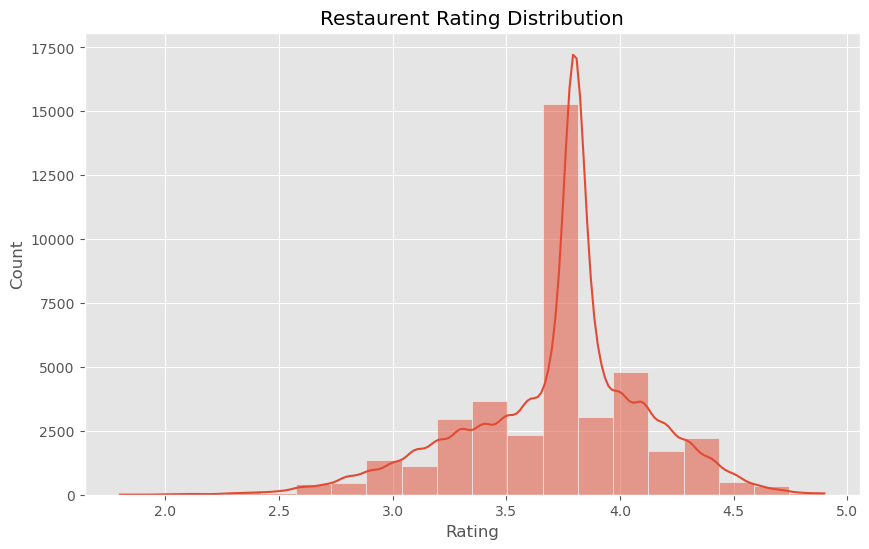

In [138]:
plt.figure(figsize=(10,6))  
sns.histplot(df['rate'],bins=20,kde=True)
plt.title("Restaurent Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count") 
plt.show()

# **Online Order Analysis**

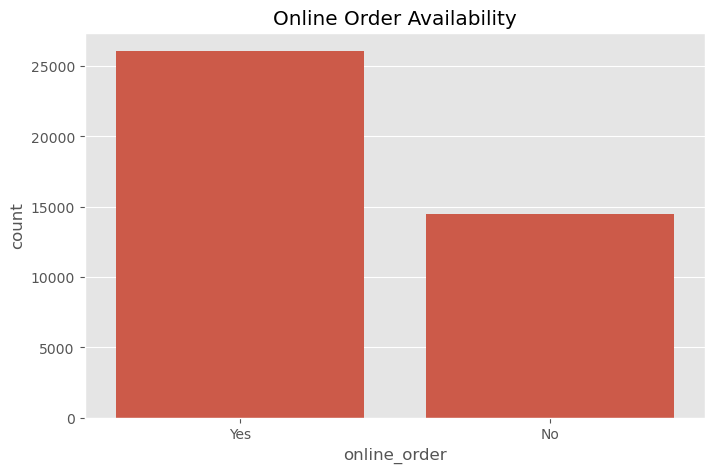

In [146]:
plt.figure(figsize=(8,5)) 
sns.countplot(x='online_order',data=df) 
plt.title("Online Order Availability") 
plt.show()

# **Table Booking Analysis**

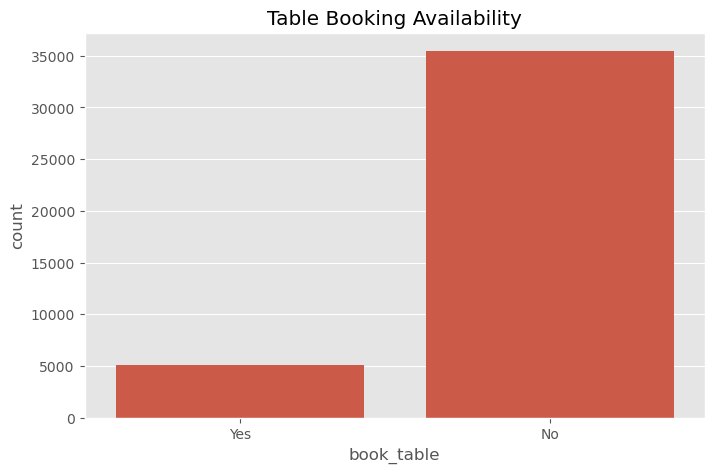

In [147]:
plt.figure(figsize=(8,5))

sns.countplot(x='book_table', data=df)

plt.title("Table Booking Availability")

plt.show()

# **Top 15 Restaurant Locations (Hotspots)**

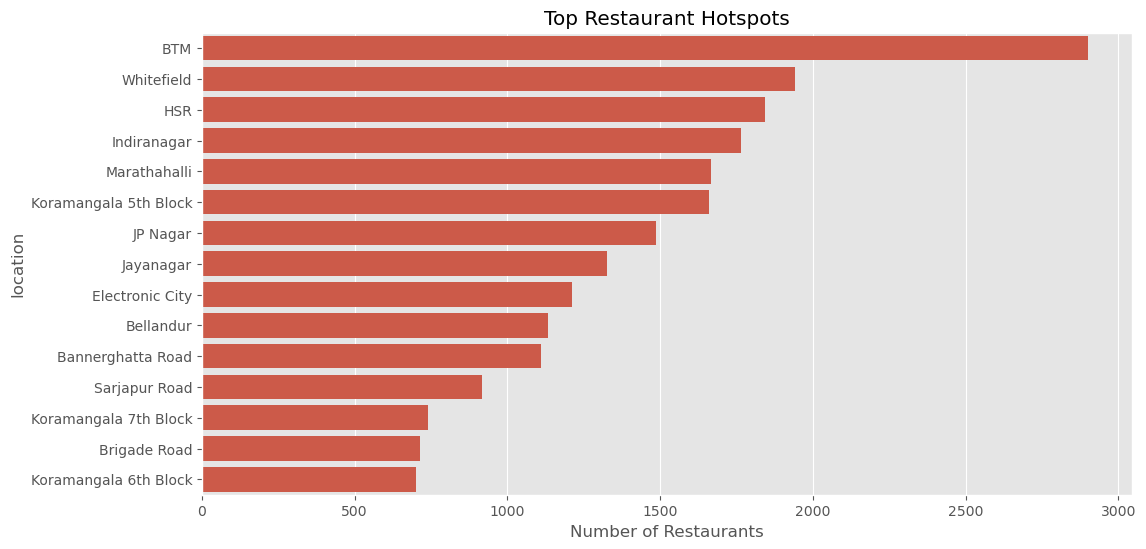

In [151]:
top_locations = df['location'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top Restaurant Hotspots")

plt.xlabel("Number of Restaurants")

plt.show()

# **Top Rated Locations**

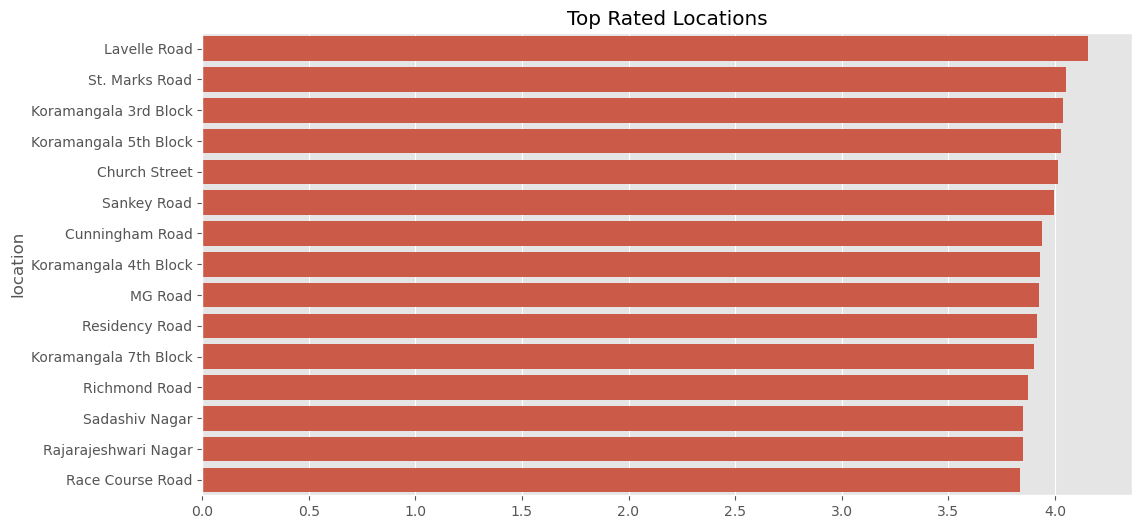

In [153]:
location_rating = (
    df.groupby('location')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=location_rating.values,
    y=location_rating.index
)

plt.title("Top Rated Locations")

plt.show()

# **Cuisine Analysis And Visualization**

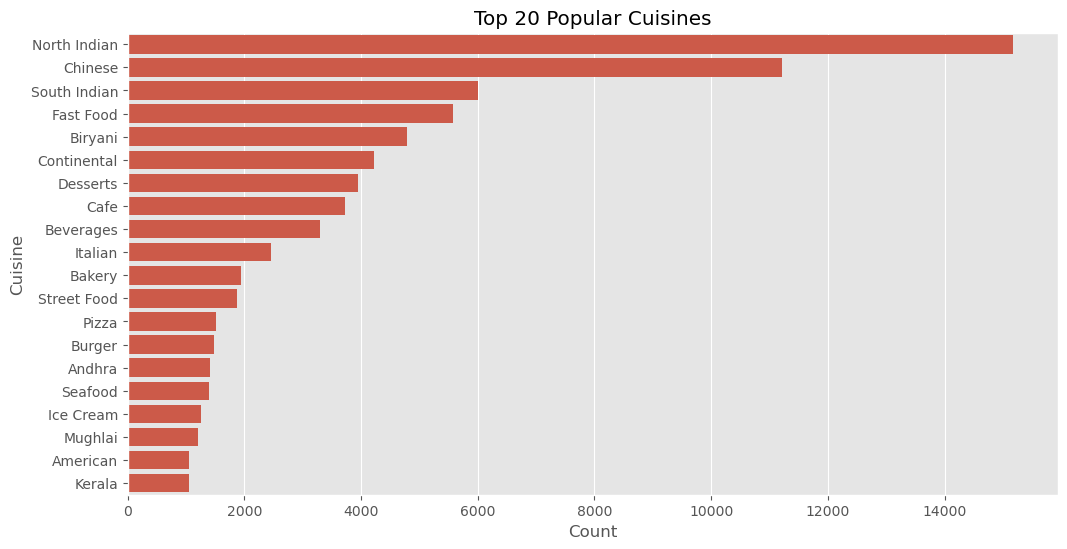

In [155]:
all_cuisines = []

for item in df['cuisines'].dropna():

    cuisines = str(item).split(',')

    for c in cuisines:
        all_cuisines.append(c.strip())

cuisine_df = pd.Series(all_cuisines)

top_cuisines = cuisine_df.value_counts().head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title("Top 20 Popular Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")

plt.show()

# **Cuisine WordCloud**

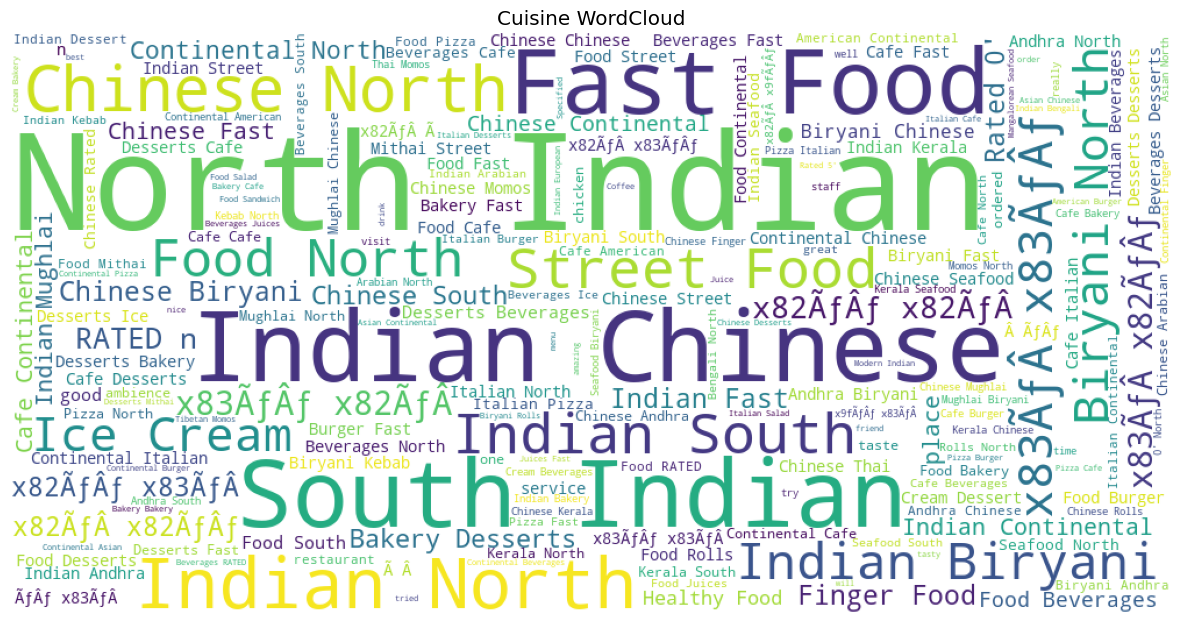

In [159]:
text = " ".join(all_cuisines)

wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wc)

plt.axis("off")

plt.title("Cuisine WordCloud")

plt.show()

# **Price vs Rating Analysis**

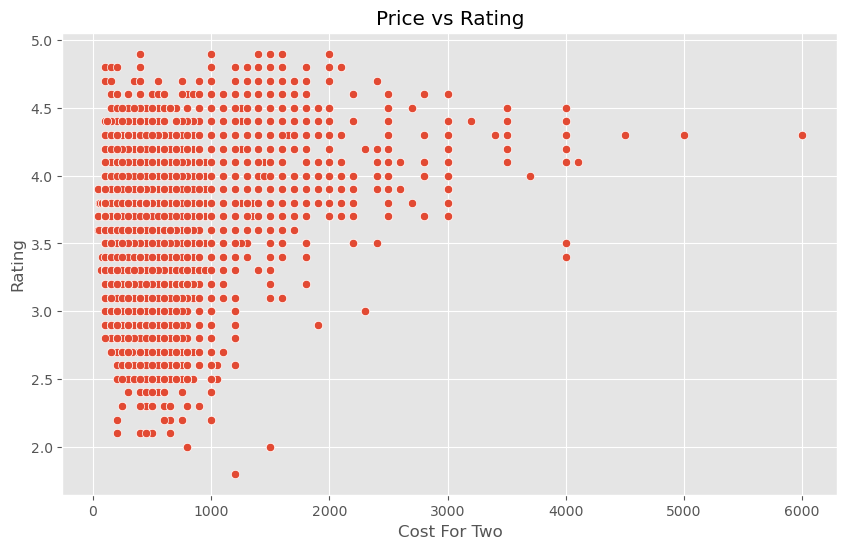

In [160]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='approx_cost(for two people)',
    y='rate',
    data=df
)

plt.title("Price vs Rating")

plt.xlabel("Cost For Two")

plt.ylabel("Rating")

plt.show()

# **Correlation Heatmap**

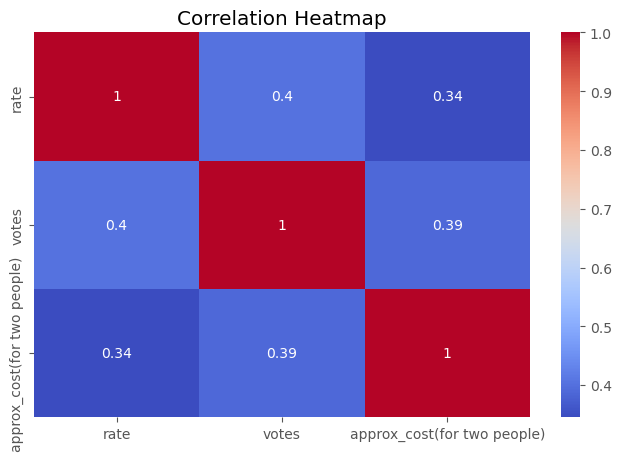

In [161]:
numeric_df = df[
    ['rate',
     'votes',
     'approx_cost(for two people)']
]

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# **Average Rating by Restaurant Type**

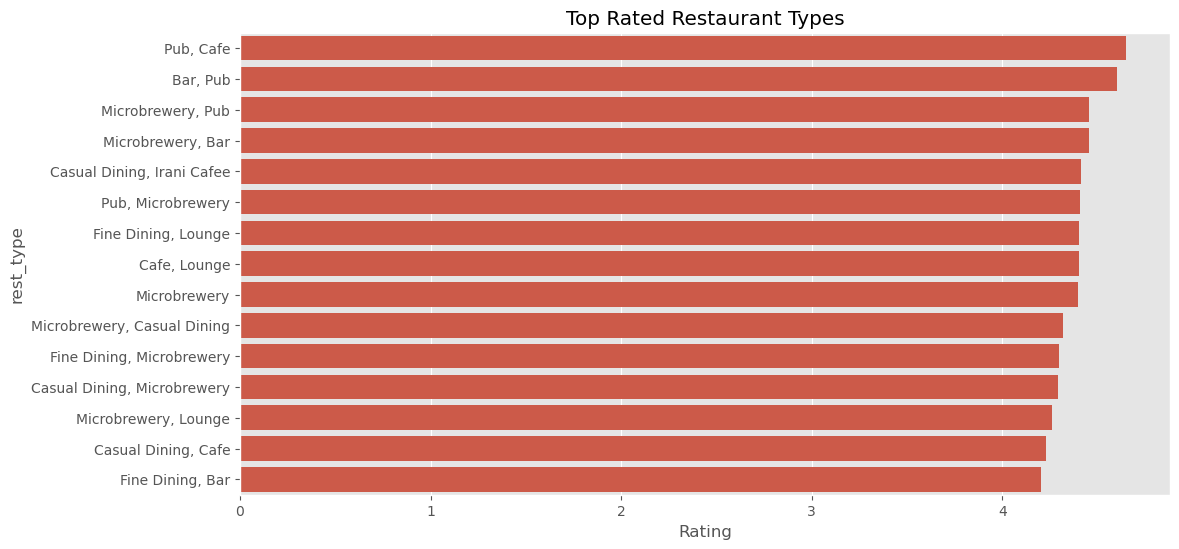

In [163]:
rest_rating = (
    df.groupby('rest_type')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=rest_rating.values,
    y=rest_rating.index
)
plt.xlabel("Rating")

plt.title("Top Rated Restaurant Types")

plt.show()

# **Most Voted Restaurants**

In [166]:
top_votes = (df[['name','votes']].sort_values('votes', ascending=False).head(10))
top_votes

,name,votes
38199,Byg Brewski Brewing Company,16832.0
4484,Byg Brewski Brewing Company,16345.0
3572,Byg Brewski Brewing Company,16345.0
17100,Toit,14956.0
16486,Toit,14956.0
28344,Truffles,14726.0
26759,Truffles,14723.0
26041,Truffles,14717.0
23889,Truffles,14710.0
22963,Truffles,14704.0


# **Relationship Analysis** 

In [169]:
print("Correlation Matrix:")
df1=pd.DataFrame(df[
        ['rate',
         'votes',
         'approx_cost(for two people)']
    ].corr()) 

df1

Correlation Matrix:


,rate,votes,approx_cost(for two people)
rate,1.000000,0.401947,0.344806
votes,0.401947,1.000000,0.385860
approx_cost(for two people),0.344806,0.385860,1.000000


# **Key Findings**

In [170]:
print("""
KEY FINDINGS

1. Most restaurants have ratings between 3.5 and 4.2.

2. Popular locations contain the highest concentration of restaurants.

3. Certain cuisines dominate customer preference.

4. Higher price does not always guarantee higher ratings.

5. Votes and ratings show positive correlation.

6. Online ordering is offered by a majority of restaurants.

7. Table booking is less common compared to online ordering.

8. A few restaurant types consistently receive higher ratings.

9. Some locations show both high restaurant density and high ratings.

10. Cuisine diversity significantly influences restaurant popularity.
""")


KEY FINDINGS

1. Most restaurants have ratings between 3.5 and 4.2.

2. Popular locations contain the highest concentration of restaurants.

3. Certain cuisines dominate customer preference.

4. Higher price does not always guarantee higher ratings.

5. Votes and ratings show positive correlation.

6. Online ordering is offered by a majority of restaurants.

7. Table booking is less common compared to online ordering.

8. A few restaurant types consistently receive higher ratings.

9. Some locations show both high restaurant density and high ratings.

10. Cuisine diversity significantly influences restaurant popularity.



# **5 Recommendations for Alfido Tech**

In [2]:
print("Recommendations fro Alfido Tech:")
recommendations = [

"Partner with top-rated restaurants in high-demand locations.",

"Develop cuisine-based recommendation engines for users.",

"Use customer ratings and votes for personalized suggestions.",

"Create content around trending cuisines and top restaurant hotspots.",

"Provide pricing intelligence dashboards helping restaurants optimize menu pricing."

]

for i,r in enumerate(recommendations,1):
    print(f"{i}. {r}")

Recommendations fro Alfido Tech:
1. Partner with top-rated restaurants in high-demand locations.
2. Develop cuisine-based recommendation engines for users.
3. Use customer ratings and votes for personalized suggestions.
4. Create content around trending cuisines and top restaurant hotspots.
5. Provide pricing intelligence dashboards helping restaurants optimize menu pricing.


# **Export Cleaned Dataset**

In [172]:
df.to_csv(
    "cleaned_zomato_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


# **Report Summary**

In [173]:
report = """

ZOMATO DATASET ANALYSIS

OBJECTIVE:
Analyze restaurant ratings, cuisines, locations and pricing.

DATA CLEANING:
- Removed duplicates
- Fixed rating values
- Handled missing values
- Converted cost to numeric

ANALYSIS:
- Rating distribution
- Location hotspots
- Popular cuisines
- Price vs rating
- Restaurant types
- Correlation analysis

VISUALIZATIONS:
- Histograms
- Bar Charts
- Heatmaps
- WordClouds
- Scatter Plots

BUSINESS RECOMMENDATIONS:
1. Strategic restaurant partnerships
2. Cuisine recommendation system
3. Personalized ranking algorithm
4. Location-based marketing
5. Pricing intelligence solutions

CONCLUSION:
Ratings are influenced more by customer experience,
restaurant type and location than price alone.
"""

print(report)



ZOMATO DATASET ANALYSIS

OBJECTIVE:
Analyze restaurant ratings, cuisines, locations and pricing.

DATA CLEANING:
- Removed duplicates
- Fixed rating values
- Handled missing values
- Converted cost to numeric

ANALYSIS:
- Rating distribution
- Location hotspots
- Popular cuisines
- Price vs rating
- Restaurant types
- Correlation analysis

VISUALIZATIONS:
- Histograms
- Bar Charts
- Heatmaps
- WordClouds
- Scatter Plots

BUSINESS RECOMMENDATIONS:
1. Strategic restaurant partnerships
2. Cuisine recommendation system
3. Personalized ranking algorithm
4. Location-based marketing
5. Pricing intelligence solutions

CONCLUSION:
Ratings are influenced more by customer experience,
restaurant type and location than price alone.

